In [1]:
import pandas as pd

In [2]:
df=pd.read_excel("C:\\Users\\OreOgunkola\\Downloads\\1591617926_data\\data.xlsx")

In [3]:
df.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605


In [4]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [5]:
df.describe(include='O')

,Restaurant Name,City,Address,Locality,Locality Verbose,Cuisines,Currency,Has Table booking,Has Online delivery,Rating color,Rating text
count,9550,9551,9551,9551,9551,9542,9551,9551,9551,9551,9551
unique,7445,141,8918,1208,1265,1825,12,2,2,6,6
top,Cafe Coffee Day,New Delhi,"Dilli Haat, INA, New Delhi",Connaught Place,"Connaught Place, New Delhi",North Indian,Indian Rupees(Rs.),No,No,Orange,Average
freq,83,5473,11,122,122,936,8652,8393,7100,3737,3737


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9550 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Price range           9551 non-null   int64  
 15  Aggregate rating     

In [7]:
df.isna().sum()

Restaurant ID           0
Restaurant Name         1
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [8]:
df[df.duplicated(subset= 'Restaurant ID')]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes


In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9546    False
9547    False
9548    False
9549    False
9550    False
Length: 9551, dtype: bool

In [10]:
df.groupby('City')['Restaurant ID'].count().idxmax()

'New Delhi'

In [11]:
df.groupby('City')['Restaurant ID'].count().idxmin()

'Armidale'

In [12]:
df[df.City.str.contains('bul')].City.value_counts()

€¡stanbul    14
Name: City, dtype: int64

In [13]:
df['City']=df.City.str.replace('€¡','I')

In [14]:
df.groupby('City')['Restaurant ID'].count()

City
Abu Dhabi          20
Agra               20
Ahmedabad          21
Albany             20
Allahabad          20
                   ..
Waterloo           20
Weirton             1
Wellington City    20
Winchester Bay      1
Yorkton             1
Name: Restaurant ID, Length: 141, dtype: int64

In [15]:
df.groupby('Restaurant Name')['Country Code'].count().idxmax()

'Cafe Coffee Day'

In [16]:
df_rest_country=pd.pivot_table(data=df,index='Restaurant Name',columns='Country Code',values='Restaurant ID',aggfunc='count').fillna(0).reset_index()

In [17]:
import numpy as np

In [18]:
df_rest_country.iloc[:,2:].applymap(lambda x:np.where(x>0,1,0))

Country Code,14,30,37,94,148,162,166,184,189,191,208,214,215,216
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7440,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7441,0,0,0,0,0,0,0,0,1,0,0,0,0,0
7442,0,0,0,0,1,0,0,0,0,0,0,0,0,0
7443,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
df_rest_country['No of countries covered']=df_rest_country.drop(columns=['Restaurant Name']).sum(axis=1)

In [20]:
df_rest_country['No of countries covered'].max()

83.0

In [21]:
df['Country Code'].value_counts()

1      8652
216     434
215      80
189      60
30       60
214      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: Country Code, dtype: int64

In [22]:
df[df['Has Table booking']=='Yes'].shape[0]

1158

In [23]:
df[df['Has Table booking']=='Yes'].shape[0]/df[df['Has Table booking']=='No'].shape[0]

0.13797211962349576

In [24]:
df[df['Has Online delivery']=='Yes'].shape[0]/df.shape[0]*100

25.662234321013504

In [25]:
df[df['Has Online delivery']=='Yes']['Votes'].sum()

517914

In [26]:
df[df['Has Online delivery']=='Yes']['Votes'].sum()-df[df['Has Online delivery']=='No']['Votes'].sum()

-462817

In [27]:
df.groupby('Cuisines')['City'].count().idxmax()

'North Indian'

In [28]:
df['Cuisines']

0                                    Italian, Continental
1                              Asian, Indonesian, Western
2                                         Sushi, Japanese
3                                                Japanese
4                                         French, Western
                              ...                        
9546                     Chinese, North Indian, Fast Food
9547                         Indian, Chinese, Continental
9548    Cafe, Continental, Desserts, Ice Cream, Italia...
9549                                          Street Food
9550                                Chinese, North Indian
Name: Cuisines, Length: 9551, dtype: object

In [29]:
cuisine=[]
for i in df.dropna(subset=['Cuisines']).Cuisines:
    x=cuisine+i.split(',')
    for j in x:
        cuisine.append(j.strip())
cuisine    

KeyboardInterrupt: 

In [58]:
cuisine=[]
for i in df.dropna(subset=['Cuisines']).Cuisines:
    x=i.split(',')
    for j in x:
        cuisine.append(j.strip())
cuisine

['Italian',
 'Continental',
 'Asian',
 'Indonesian',
 'Western',
 'Sushi',
 'Japanese',
 'Japanese',
 'French',
 'Western',
 'Cafe',
 'Western',
 'Indonesian',
 'Peranakan',
 'Indonesian',
 'Western',
 'Asian',
 'Cafe',
 'Sunda',
 'Indonesian',
 'Korean',
 'Desserts',
 'Bakery',
 'Western',
 'Japanese',
 'Sushi',
 'Ramen',
 'Sunda',
 'Indonesian',
 'Sunda',
 'Indonesian',
 'Cafe',
 'Italian',
 'Coffee and Tea',
 'Western',
 'Indonesian',
 'Cafe',
 'Coffee and Tea',
 'Western',
 'Burger',
 'Seafood',
 'Western',
 'Seafood',
 'Western',
 'Cafe',
 'Desserts',
 'Beverages',
 'European',
 'Asian',
 'Japanese',
 'Korean',
 'Thai',
 'Chinese',
 'North Indian',
 'European',
 'Asian',
 'Indian',
 'European',
 'Continental',
 'North Indian',
 'Chinese',
 'South Indian',
 'Italian',
 'Malaysian',
 'Thai',
 'Kerala',
 'Vietnamese',
 'Sri Lankan',
 'Japanese',
 'Sushi',
 'Japanese',
 'Sushi',
 'Chinese',
 'Continental',
 'North Indian',
 'Italian',
 'Asian',
 'South American',
 'Chinese',
 'Italian

In [59]:
pd.Series(cuisine).value_counts().head(10)

North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
dtype: int64

In [60]:
# define a function which gives count of elements in cells
z='Italian,Continental'

In [61]:
def countCuisine(x):
    return(len(x.split(',')))

In [62]:
df.dropna(subset=['Cuisines'],inplace=True)

In [63]:
df['Count_ofCuisines']=df.Cuisines.apply(countCuisine)

In [68]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Count_ofCuisines
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498,2
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873,3
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605,2
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395,1
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243,2


In [69]:
df.Count_ofCuisines.max()

8

In [70]:
df[df.Count_ofCuisines==8]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Count_ofCuisines
990,18318116,R' ADDA,1,Mumbai,"Ramee Guestline Hotel, 462, A B Nair Road, Juh...","Ramee Guestline Hotel, Juhu","Ramee Guestline Hotel, Juhu, Mumbai",72.825451,19.109300,"Street Food, Burger, Desserts, Italian, Pizza,...",1200,Indian Rupees(Rs.),No,No,3,4.0,Green,Very Good,536,8
1255,18463285,Mumbai Vibe,1,Mumbai,"Ganga Jamuna Block, 14th Road, Linking Road, B...","Linking Road, Bandra West","Linking Road, Bandra West, Mumbai",72.832658,19.065838,"Cafe, Continental, North Indian, Italian, Chin...",1000,Indian Rupees(Rs.),Yes,No,3,3.8,Yellow,Good,146,8
1456,18370704,Marble,189,Johannesburg,"Corner Jan Smuts Avenue & Jellicoe Avenue, Ros...",Rosebank,"Rosebank, Johannesburg",28.036199,-26.143388,"Continental, South African, Beverages, Dessert...",955,Rand(R),No,No,4,4.5,Dark Green,Excellent,222,8
2783,313316,Bikanervala,1,Gurgaon,"Suncity Business Tower, Golf Course Road, Gurgaon","Suncity Business Tower, Golf Course Road","Suncity Business Tower, Golf Course Road, Gurgaon",77.105322,28.433507,"North Indian, South Indian, Fast Food, Street ...",600,Indian Rupees(Rs.),No,Yes,2,3.4,Orange,Average,178,8
3271,18279982,Indian Summer Cafe,1,Patna,"Satya Narain Building, Exhibition Road, Golamb...",Golambar,"Golambar, Patna",85.142625,25.609788,"Continental, Cafe, Italian, Pizza, North India...",600,Indian Rupees(Rs.),No,No,2,3.4,Orange,Average,16,8
3359,305303,Bikanervala,1,New Delhi,"7, Masjid Moth, Near HDFC Bank, Greater Kailas...",Greater Kailash (GK) 2,"Greater Kailash (GK) 2, New Delhi",77.238937,28.537319,"North Indian, South Indian, Fast Food, Street ...",550,Indian Rupees(Rs.),No,Yes,2,3.5,Yellow,Good,272,8
3389,491,Bikanervala,1,New Delhi,"A-80, Central Market, Near Axis Bank, Lajpat N...",Lajpat Nagar 2,"Lajpat Nagar 2, New Delhi",77.239033,28.571075,"North Indian, South Indian, Fast Food, Street ...",550,Indian Rupees(Rs.),No,Yes,2,3.7,Yellow,Good,269,8
3406,492,Bikanervala,1,New Delhi,"1, ITL Twin Tower, Netaji Subhash Place, New D...",Netaji Subhash Place,"Netaji Subhash Place, New Delhi",77.152022,28.691296,"North Indian, South Indian, Fast Food, Street ...",550,Indian Rupees(Rs.),No,Yes,2,3.4,Orange,Average,89,8
3425,497,Bikanervala,1,New Delhi,"A-2/43, 1st Floor, Rajouri Garden, New Delhi",Rajouri Garden,"Rajouri Garden, New Delhi",77.122740,28.648536,"North Indian, South Indian, Fast Food, Street ...",550,Indian Rupees(Rs.),No,No,2,3.8,Yellow,Good,334,8
3442,18446491,Bikanervala,1,New Delhi,"Level 2, Food Capital, Worldmark 1, Aerocity, ...","Worldmark 1, Aerocity","Worldmark 1, Aerocity, New Delhi",77.121424,28.549895,"North Indian, South Indian, Fast Food, Street ...",550,Indian Rupees(Rs.),No,No,2,0.0,White,Not rated,3,8


In [71]:
df[df.Count_ofCuisines==df.Count_ofCuisines.min()]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Count_ofCuisines
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395,1
6,18386856,Onokabe,94,Tangerang,"Alam Sutera Town Center, Jl. Alam Utama, Serpo...","Alam Sutera Town Center, Serpong Utara","Alam Sutera Town Center, Serpong Utara, Tangerang",106.652688,-6.241792,Indonesian,300000,Indonesian Rupiah(IDR),No,No,3,3.7,Yellow,Good,155,1
10,18425821,OJJU,94,Jakarta,"Gandaria City, Lantai Upper Ground, Jl. Sultan...","Gandaria City Mall, Gandaria","Gandaria City Mall, Gandaria, Jakarta",106.783162,-6.244221,Korean,200000,Indonesian Rupiah(IDR),No,No,3,3.9,Yellow,Good,137,1
17,18370659,Flip Burger,94,Jakarta,"Jl. Senopati No. 27, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.808550,-6.230775,Burger,120000,Indonesian Rupiah(IDR),No,No,3,4.4,Green,Very Good,410,1
21,2701,Orient Express - Taj Palace Hotel,1,New Delhi,"Taj Palace Hotel, Diplomatic Enclave, Chanakya...","The Taj Palace Hotel, Chanakyapuri","The Taj Palace Hotel, Chanakyapuri, New Delhi",77.170087,28.595008,European,8000,Indian Rupees(Rs.),Yes,No,4,4.0,Green,Very Good,145,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9528,6900714,Pepe's Piri Piri,215,Birmingham,"254-256 Alum Rock Road, Alum Rock, Birmingham ...",Alum Rock,"Alum Rock, Birmingham",-1.846811,52.488557,Fast Food,10,Pounds(å£),No,No,1,2.8,Orange,Average,26,1
9534,17284302,El Vaquero Mexican Restaurant,216,Albany,"2700 Dawson Rd, Albany, GA 31707",Albany,"Albany, Albany",-84.219400,31.615800,Mexican,0,Dollar($),No,No,1,3.4,Orange,Average,45,1
9537,17334679,Azteca,216,Davenport,"4811 N Brady St Ste 3, Davenport, IA 52806",Davenport,"Davenport, Davenport",-90.568300,41.569900,Mexican,0,Dollar($),No,No,1,4.3,Green,Very Good,167,1
9541,17582627,Senor Iguanas,216,Pocatello,"961 Hiline Rd, Pocatello, ID 83201",Pocatello,"Pocatello, Pocatello",-112.443300,42.894200,Mexican,0,Dollar($),No,No,1,3.6,Yellow,Good,108,1


In [72]:
df[['City','Cuisines']]

,City,Cuisines
0,Jakarta,"Italian, Continental"
1,Jakarta,"Asian, Indonesian, Western"
2,Jakarta,"Sushi, Japanese"
3,Jakarta,Japanese
4,Jakarta,"French, Western"
...,...,...
9546,Dehradun,"Chinese, North Indian, Fast Food"
9547,Kanpur,"Indian, Chinese, Continental"
9548,Kanpur,"Cafe, Continental, Desserts, Ice Cream, Italia..."
9549,Varanasi,Street Food


In [73]:
df.Cuisines.str.split(',',expand=True)

,0,1,2,3,4,5,6,7
0,Italian,Continental,None,None,None,None,None,None
1,Asian,Indonesian,Western,None,None,None,None,None
2,Sushi,Japanese,None,None,None,None,None,None
3,Japanese,None,None,None,None,None,None,None
4,French,Western,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...
9546,Chinese,North Indian,Fast Food,None,None,None,None,None
9547,Indian,Chinese,Continental,None,None,None,None,None
9548,Cafe,Continental,Desserts,Ice Cream,Italian,Beverages,None,None
9549,Street Food,None,None,None,None,None,None,None


In [74]:
for i in set(cuisine):
    df[i]=np.where(df.Cuisines.str.contains(i),1,0)

In [75]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       ...
       'Fusion', 'Cantonese', 'Indian', 'Asian', 'Patisserie', 'Juices',
       'Restaurant Cafe', 'Mexican', 'Armenian', 'Teriyaki'],
      dtype='object', length=165)

In [76]:
df.groupby('City').agg({'Cuisines':'unique'}).reset_index()

,City,Cuisines
0,Abu Dhabi,"[Indian, Thai, Japanese, Chinese, Indonesian, ..."
1,Agra,"[North Indian, Mughlai, Mughlai, North Indian,..."
2,Ahmedabad,"[Continental, Chinese, North Indian, North Ind..."
3,Albany,"[Steak, Tapas, Bar Food, Japanese, Steak, Sush..."
4,Allahabad,"[Continental, Italian, North Indian, Mughlai, ..."
...,...,...
135,Waterloo,"[American, Italian, Seafood, Japanese, Sushi, ..."
136,Weirton,"[Burger, Greek, Sandwich]"
137,Wellington City,"[French, Kiwi, European, Italian, Cafe, Asian,..."
138,Winchester Bay,"[Burger, Seafood, Steak]"


In [77]:
res=df.groupby('City')[list(set(cuisine))].sum().reset_index()

In [78]:
result=pd.melt(res,id_vars=['City'])

In [79]:
for i in set(cuisine):
    df[i]=np.where(df.Cuisines.str.contains(i),1,0)
res=df.groupby('City')[list(set(cuisine))].sum().reset_index()
result=pd.melt(res,id_vars=['City'])
result_new=result.groupby(['City','variable'])['value'].sum().reset_index()
result_new.head(1)
result_new.sort_values(['City','value'],ascending=[True,False],inplace=True)
result_new.groupby('City').first()

,variable,value
City,,
Abu Dhabi,Indian,7
Agra,Indian,16
Ahmedabad,Continental,12
Albany,American,4
Allahabad,Indian,13
...,...,...
Waterloo,American,5
Weirton,Burger,1
Wellington City,Cafe,9


In [80]:
df.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Fusion,Cantonese,Indian,Asian,Patisserie,Juices,Restaurant Cafe,Mexican,Armenian,Teriyaki
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",...,0,0,0,0,0,0,0,0,0,0
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",...,0,0,0,1,0,0,0,0,0,0
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",...,0,0,0,0,0,0,0,0,0,0


In [30]:
df.Currency.value_counts()

Indian Rupees(Rs.)        8652
Dollar($)                  482
Pounds(å£)                  80
Emirati Diram(AED)          60
Brazilian Real(R$)          60
Rand(R)                     60
NewZealand($)               40
Turkish Lira(TL)            34
Botswana Pula(P)            22
Indonesian Rupiah(IDR)      21
Qatari Rial(QR)             20
Sri Lankan Rupee(LKR)       20
Name: Currency, dtype: int64

In [90]:
from matplotlib import pyplot as plt, style
import seaborn as sns
style.use('ggplot')

C:\Users\OreOgunkola\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


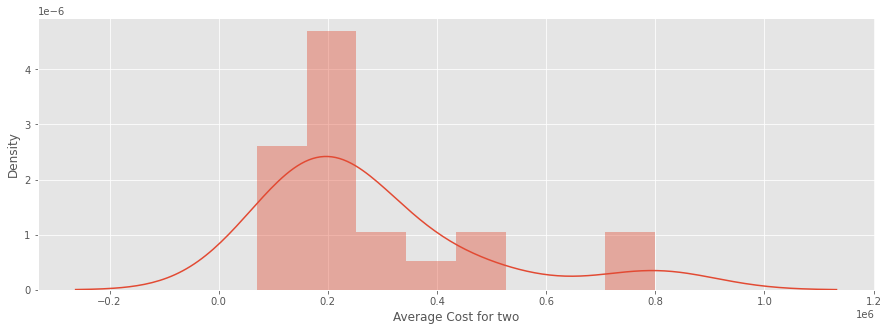

In [38]:
plt.figure(figsize=(15,5))
sns.distplot(df[df['Average Cost for two']>10000]['Average Cost for two'])
plt.show()

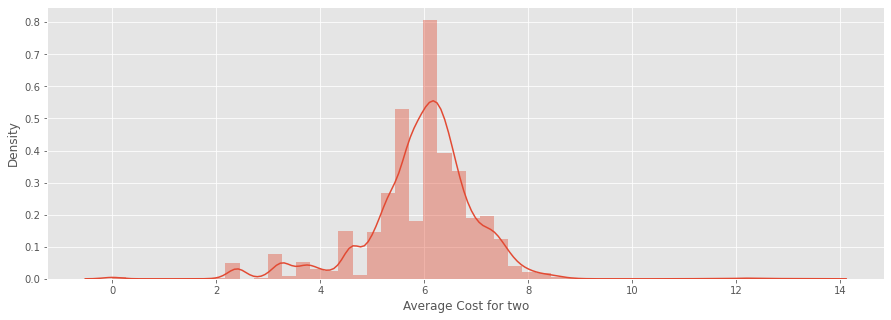

In [40]:
plt.figure(figsize=(15,5))
sns.distplot(np.log1p(df['Average Cost for two']))
plt.show()

In [41]:
df.head(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873


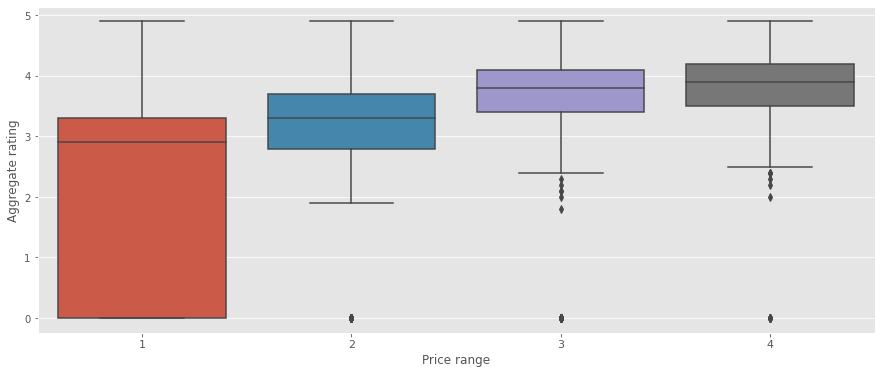

In [44]:
# box plot for Ratings vs Category
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='Price range',y='Aggregate rating')
plt.xticks(fontsize=11,rotation='horizontal')
plt.show()

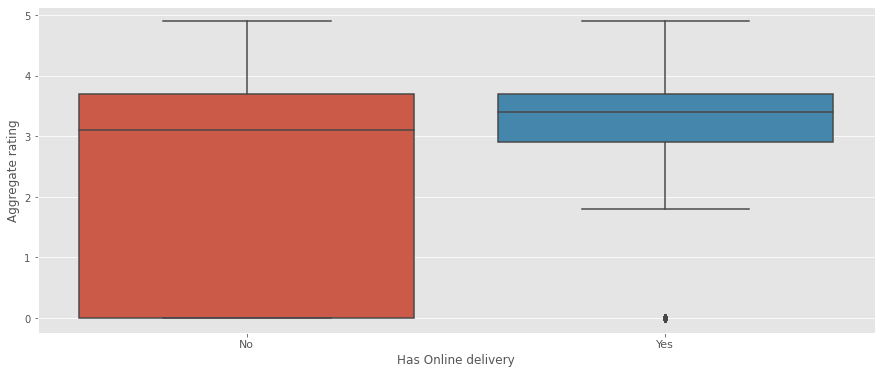

In [47]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='Has Online delivery',y='Aggregate rating')
plt.xticks(fontsize=11,rotation='horizontal')
plt.show()

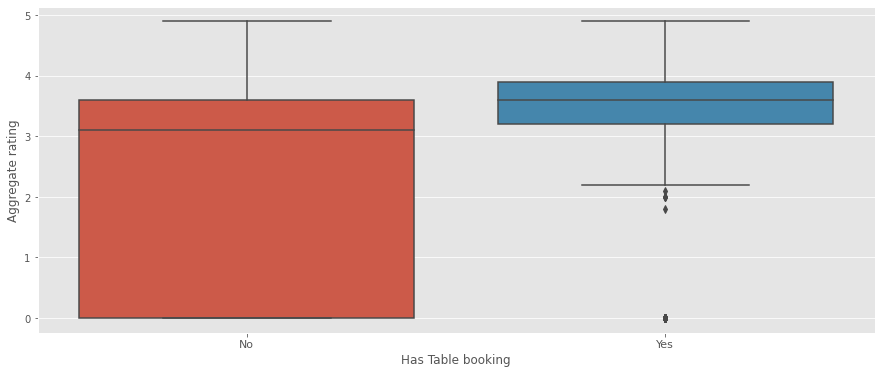

In [48]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='Has Table booking',y='Aggregate rating')
plt.xticks(fontsize=11,rotation='horizontal')
plt.show()

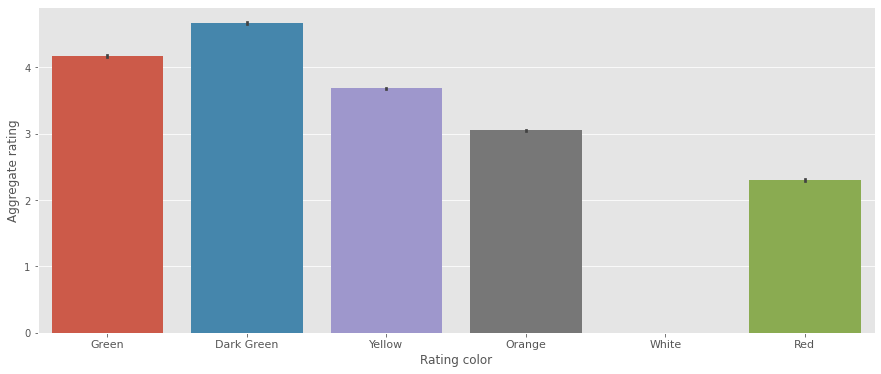

In [53]:
plt.figure(figsize=(15,6))
sns.barplot(data=df,x='Rating color',y='Aggregate rating')
plt.xticks(fontsize=11,rotation='horizontal')
plt.show()

In [50]:
sns.pairplot(df)

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x00000276014C2E50> (for post_execute):


KeyboardInterrupt: 

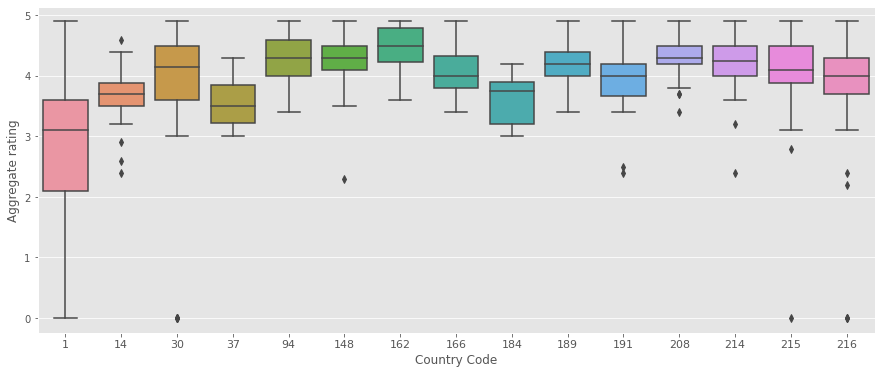

In [52]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='Country Code',y='Aggregate rating')
plt.xticks(fontsize=11,rotation='horizontal')
plt.show()

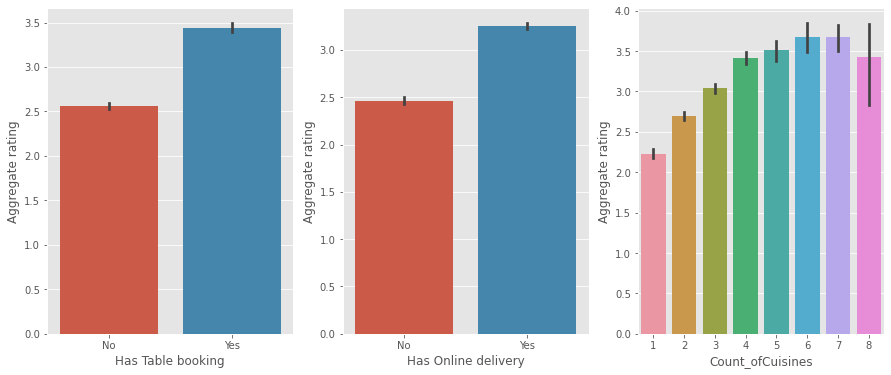

In [65]:
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
sns.barplot(data=df,x="Has Table booking",y="Aggregate rating")
plt.subplot(1,3,2)
sns.barplot(data=df,x="Has Online delivery",y="Aggregate rating")
plt.subplot(1,3,3)
sns.barplot(data=df,x="Count_ofCuisines",y="Aggregate rating")
plt.show()

In [83]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       ...
       'Fusion', 'Cantonese', 'Indian', 'Asian', 'Patisserie', 'Juices',
       'Restaurant Cafe', 'Mexican', 'Armenian', 'Teriyaki'],
      dtype='object', length=165)

In [ ]:
df.groupby('Count_ofCuisine')['Aggregate rating']

In [81]:
pip install wordcloud

In [82]:
from wordcloud import WordCloud

In [92]:
wc=WordCloud().generate_from_text(','.join(cuisine))

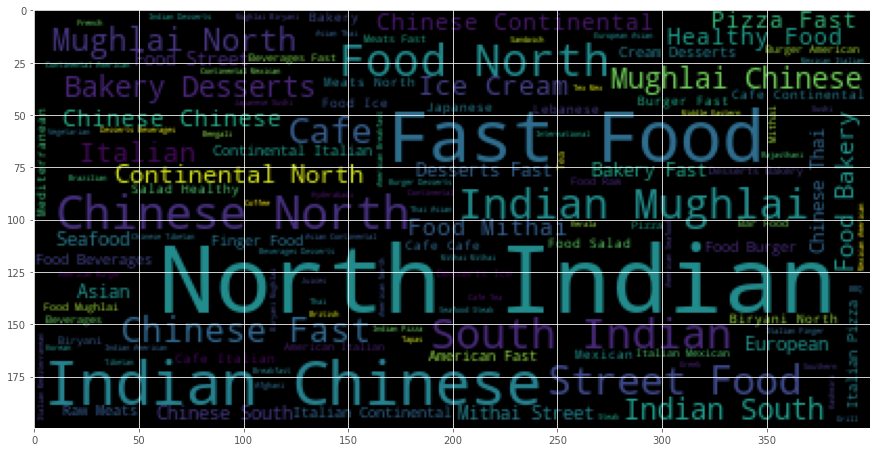

In [94]:
plt.figure(figsize=(15,15))
plt.imshow(wc)
plt.show()

In [93]:
wc1=WordCloud().generate_from_frequencies(pd.Series(cuisine).value_counts())

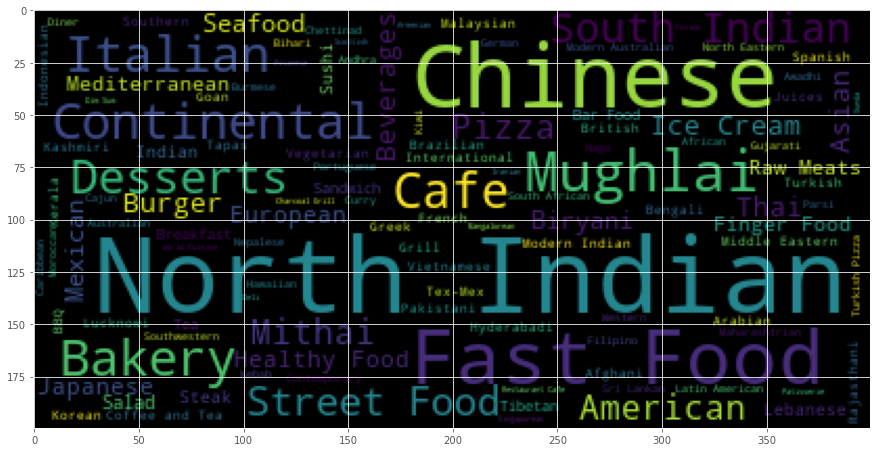

In [95]:
plt.figure(figsize=(15,15))
plt.imshow(wc1)
plt.show()

In [96]:
res=df['Has Table booking'].value_counts()

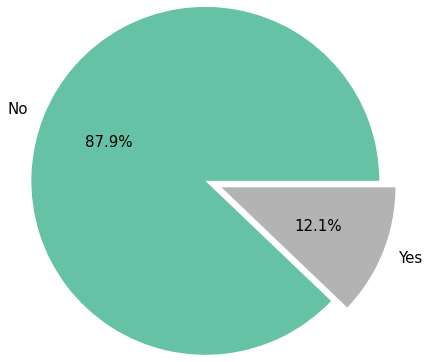

In [98]:
res.plot.pie(radius=2,autopct='%1.1f%%',textprops={'size':15},explode=[0.1,0.1],cmap='Set2')
plt.ylabel('Table')
plt.show()